In [21]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [32]:
env = gym.make("FrozenLake-v1",
               desc=[
                   "FFSF",
                   "FFFF",
                   "FFFF",
                   "FFGF"

],is_slippery=True)


num_states = env.observation_space.n
num_actions = env.action_space.n


In [33]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1
gamma = 0.99

# Variable epsilon
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

In [34]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((num_states, num_actions))



# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):

    if np.random.random() < epsilon:
        # Exploration
        return env.action_space.sample()

    else:
        # Exploitation
        return np.argmax(Q[state])





In [35]:

# -------------------------------------------------
# SARSA Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):

    # Environment decides the initial state
    state, info = env.reset()

    # Select first action using current epsilon
    action = epsilon_greedy_action(state, epsilon)

    total_reward = 0

    for step in range(max_steps_per_episode):

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        # If episode has not ended,
        # select next action using current policy
        if not terminated and not truncated:
            next_action = epsilon_greedy_action(
                next_state, epsilon
            )

            # SARSA target
            td_target = (
                reward
                + gamma * Q[next_state, next_action]
            )

        else:
            # No next action for terminal state
            next_action = None

            td_target = reward

        # SARSA update
        td_error = td_target - Q[state, action]

        Q[state, action] = (
            Q[state, action]
            + alpha * td_error
        )

        # Stop if episode is finished
        if terminated or truncated:
            break

        # Move to next state and action
        state = next_state
        action = next_action

    episode_rewards.append(total_reward)

    # -------------------------------------------------
    # Variable Epsilon Decay
    # -------------------------------------------------

    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )



In [36]:

# -------------------------------------------------
# State-Value Function and Policy
# -------------------------------------------------

state_values = np.max(Q, axis=1)

learned_policy = np.argmax(Q, axis=1)




In [37]:

# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):

    print("\nEstimated State-Value Function:")

    print(
        np.round(
            values.reshape(4, 4),
            3
        )
    )


def print_policy(policy):

    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [
            action_symbols[action]
            for action in policy
        ]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)



In [38]:

# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")

print(
    np.round(Q, 3)
)

print_value_function(state_values)

print_policy(learned_policy)

average_reward = np.mean(
    episode_rewards[-1000:]
)

print(
    "\nAverage reward over last 1000 episodes:",
    average_reward
)

print(
    "\nFinal epsilon:",
    epsilon
)





Final Q-table:
[[0.796 0.874 0.827 0.792]
 [0.876 0.87  0.877 0.862]
 [0.88  0.888 0.88  0.878]
 [0.882 0.88  0.88  0.878]
 [0.875 0.888 0.872 0.871]
 [0.888 0.9   0.889 0.884]
 [0.898 0.914 0.897 0.892]
 [0.896 0.911 0.899 0.898]
 [0.895 0.904 0.895 0.9  ]
 [0.905 0.931 0.912 0.903]
 [0.926 0.952 0.932 0.934]
 [0.94  0.95  0.939 0.936]
 [0.903 0.902 0.903 0.913]
 [0.92  0.929 0.958 0.926]
 [0.    0.    0.    0.   ]
 [0.965 0.98  0.961 0.965]]

Estimated State-Value Function:
[[0.874 0.877 0.888 0.882]
 [0.888 0.9   0.914 0.911]
 [0.904 0.931 0.952 0.95 ]
 [0.913 0.958 0.    0.98 ]]

Learned Policy:
[['D' 'R' 'D' 'L']
 ['D' 'D' 'D' 'D']
 ['D' 'D' 'D' 'D']
 ['U' 'R' 'L' 'D']]

Average reward over last 1000 episodes: 1.0

Final epsilon: 0.05


SURESH S
212223040215


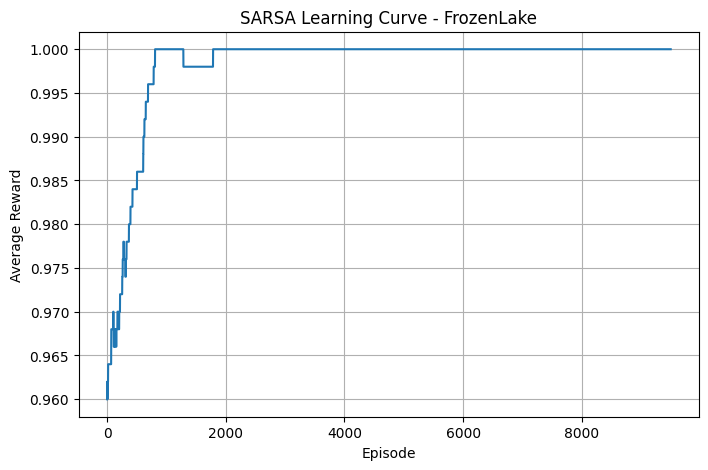

In [40]:

# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

print("SURESH S")
print("212223040215")
window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))

plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "SARSA Learning Curve - FrozenLake"
)

plt.grid(True)

plt.show()

env.close()